# Laboratorio 03 - Modelos de Regresion Lineal

**Curso:** Mineria de Datos  
**Dataset:** House Prices: Advanced Regression Techniques (Kaggle)  
**Archivo principal:** `train.csv`  
**Objetivo:** predecir `SalePrice` con modelos de regresion lineal y seleccionar el mejor modelo para generalizar.

## 1. Introduccion

Este notebook resuelve de forma completa el laboratorio de regresion lineal con el dataset **House Prices**.
Se trabaja sobre `train.csv` como base principal y la evaluacion se realiza con un subconjunto de prueba extraido desde ese mismo archivo.

### Objetivo del laboratorio
Construir, diagnosticar y comparar modelos de regresion lineal para predecir `SalePrice`, justificando cual modelo generaliza mejor.

In [1]:
from pathlib import Path
import warnings
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from sklearn.decomposition import PCA

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "data" / "raw" / "train.csv").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontro data/raw/train.csv. Coloque el dataset en esa ruta."
    )

PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)

Project root: /Users/javiervalladares/Library/Mobile Documents/com~apple~CloudDocs/Séptimo semestre/Mineria de datos/lab3
Data dir: /Users/javiervalladares/Library/Mobile Documents/com~apple~CloudDocs/Séptimo semestre/Mineria de datos/lab3/data/raw


## 2. Carga y descripcion de datos (Inciso 1)

In [2]:
train_path = DATA_DIR / "train.csv"
if not train_path.exists():
    raise FileNotFoundError(
        "Falta train.csv en data/raw/. Descarguelo de Kaggle y coloquelo en esa ruta."
    )

df = pd.read_csv(train_path)
if "SalePrice" not in df.columns:
    raise ValueError("La variable objetivo SalePrice no existe en train.csv")

display(df.head(3))
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print("Objetivo:", "SalePrice")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


Dimensiones: 1460 filas x 81 columnas
Objetivo: SalePrice


### Descripcion de variables (Inciso 1)

In [3]:
# Tabla de descripcion de variables
variable_description = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "n_missing": df.isna().sum().values,
    "missing_%": (df.isna().mean().values * 100).round(2),
    "n_unique": [df[col].nunique(dropna=True) for col in df.columns],
})

print("Variable respuesta identificada:", "SalePrice")
print("Total de variables:", df.shape[1])

# Vista completa de metadatos de columnas
display(variable_description)

# Vista resumida por tipo
summary_by_type = variable_description.groupby("dtype", as_index=False).agg(
    cantidad_variables=("variable", "count"),
    missing_promedio=("missing_%", "mean"),
)
display(summary_by_type.sort_values("cantidad_variables", ascending=False))

# Si existe diccionario oficial de variables, mostrar evidencia
data_desc_path = DATA_DIR / "data_description.txt"
if data_desc_path.exists():
    print("Archivo data_description.txt encontrado:", data_desc_path)
    with open(data_desc_path, "r", encoding="utf-8", errors="ignore") as f:
        preview_lines = [next(f).rstrip("\n") for _ in range(20)]
    print("\nPrimeras lineas del diccionario de datos:")
    print("\n".join(preview_lines))
else:
    print("No se encontro data_description.txt; el notebook sigue siendo funcional con train.csv.")

Variable respuesta identificada: SalePrice
Total de variables: 81


,variable,dtype,n_missing,missing_%,n_unique
0,Id,int64,0,0.00,1460
1,MSSubClass,int64,0,0.00,15
2,MSZoning,object,0,0.00,5
3,LotFrontage,float64,259,17.74,110
4,LotArea,int64,0,0.00,1073
...,...,...,...,...,...
76,MoSold,int64,0,0.00,12
77,YrSold,int64,0,0.00,5
78,SaleType,object,0,0.00,9
79,SaleCondition,object,0,0.00,6


,dtype,cantidad_variables,missing_promedio
2,object,43,11.916047
1,int64,35,0.000000
0,float64,3,7.946667


Archivo data_description.txt encontrado: /Users/javiervalladares/Library/Mobile Documents/com~apple~CloudDocs/Séptimo semestre/Mineria de datos/lab3/data/raw/data_description.txt

Primeras lineas del diccionario de datos:
MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale

## 3. Analisis exploratorio (Inciso 2)

**Inciso 2:** EDA extenso con interpretaciones, outliers, correlaciones y hallazgos utiles para predecir `SalePrice`.

In [4]:
n_rows, n_cols = df.shape
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_top = missing_pct[missing_pct > 0].head(15).to_frame("missing_%")

dtypes_table = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="cantidad_columnas")
)

print(f"Variables numericas: {len(num_cols)}")
print(f"Variables categoricas: {len(cat_cols)}")

display(dtypes_table)
display(missing_top)

Variables numericas: 38
Variables categoricas: 43


,dtype,cantidad_columnas
0,object,43
1,int64,35
2,float64,3


,missing_%
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageYrBlt,5.547945
GarageCond,5.547945
GarageType,5.547945


**Interpretacion EDA inicial**
- El dataset mezcla variables numericas y categoricas, por lo que el preprocesamiento es indispensable.
- Los faltantes no son marginales en varias columnas, especialmente amenidades especificas.
- Esto impacta directamente la regresion lineal si no se corrige.

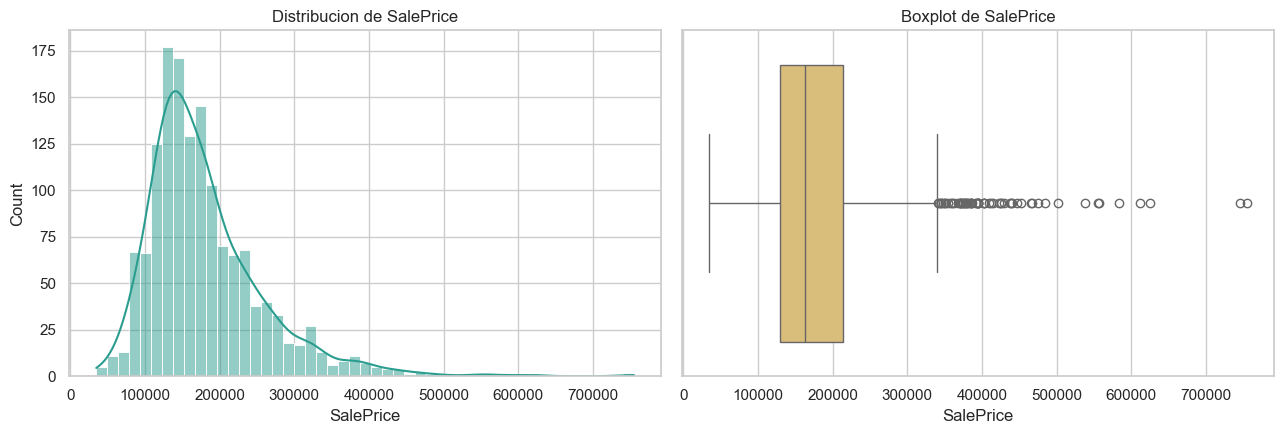

Skewness SalePrice: 1.883
Kurtosis SalePrice: 6.536


In [5]:
saleprice_skew = df["SalePrice"].skew()
saleprice_kurt = df["SalePrice"].kurtosis()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Distribucion de SalePrice")

sns.boxplot(x=df["SalePrice"], ax=axes[1], color="#e9c46a")
axes[1].set_title("Boxplot de SalePrice")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_saleprice_distribution.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"Skewness SalePrice: {saleprice_skew:.3f}")
print(f"Kurtosis SalePrice: {saleprice_kurt:.3f}")

**Interpretacion distribucion objetivo**
- `SalePrice` presenta asimetria positiva.
- Este sesgo puede afectar supuestos de normalidad y homocedasticidad en regresion lineal.
- Por eso se evaluara `log1p(SalePrice)` para entrenar modelos.

,corr_saleprice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


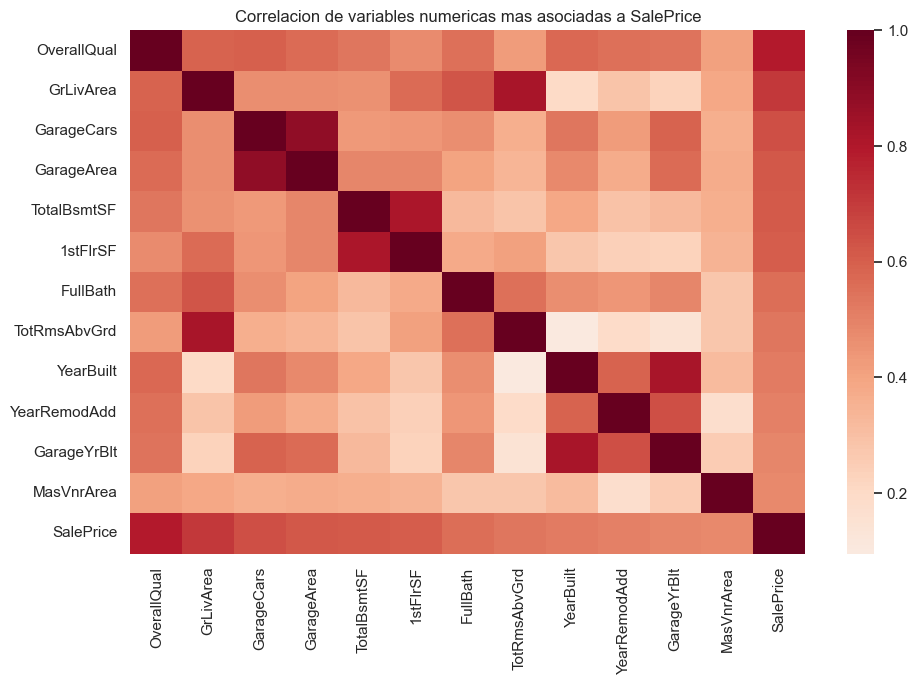

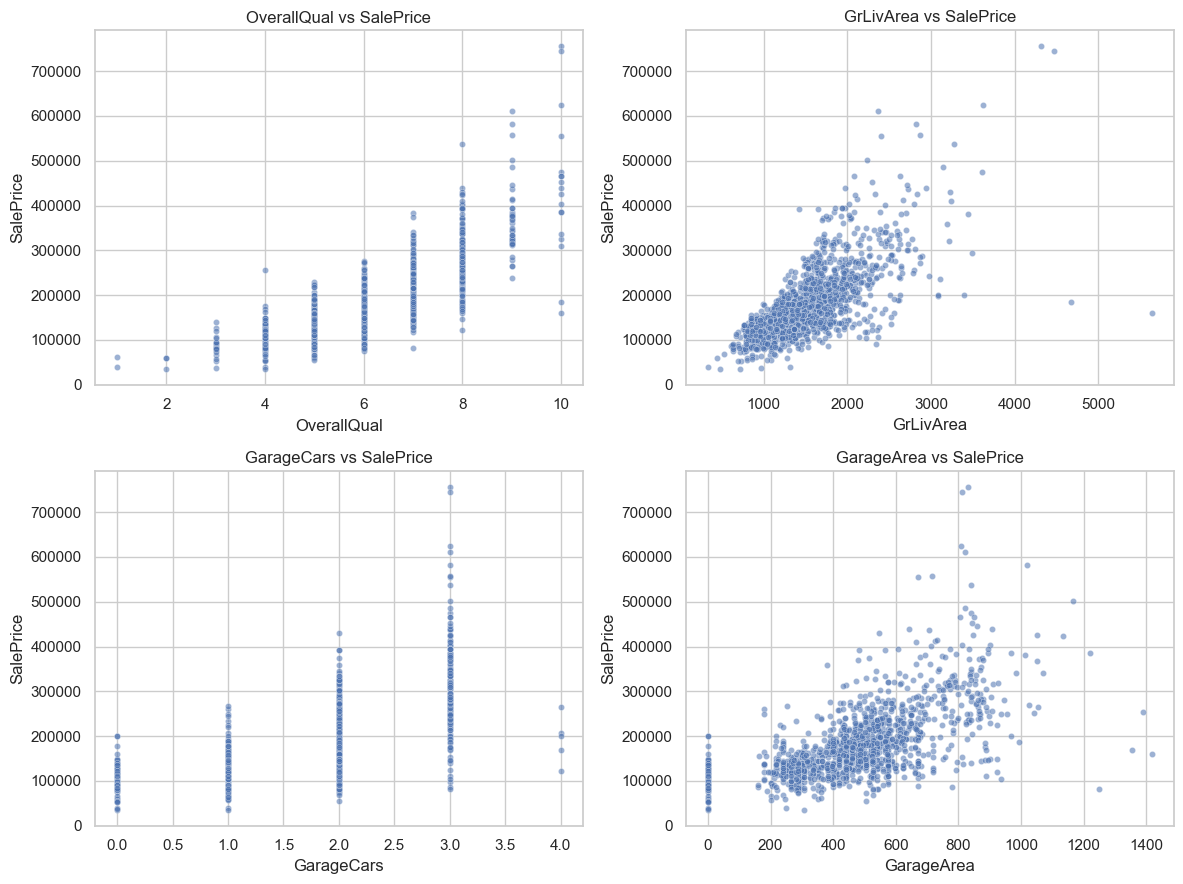

In [6]:
corr_with_target = (
    df[num_cols]
    .corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_top = corr_with_target.head(12)
display(corr_top.to_frame("corr_saleprice"))

heatmap_vars = corr_top.index.tolist() + ["SalePrice"]
plt.figure(figsize=(10, 7))
sns.heatmap(df[heatmap_vars].corr(), cmap="RdBu_r", center=0)
plt.title("Correlacion de variables numericas mas asociadas a SalePrice")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_top_correlation_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

top_scatter = corr_top.index[:4].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feature in zip(axes.flat, top_scatter):
    sns.scatterplot(data=df, x=feature, y="SalePrice", alpha=0.55, s=20, ax=ax)
    ax.set_title(f"{feature} vs SalePrice")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_top_numeric_scatter.png", dpi=140, bbox_inches="tight")
plt.show()

**Interpretacion variables numericas**
- Las variables mas correlacionadas con `SalePrice` concentran informacion predictiva.
- Se observan relaciones claras en calidad, metraje y atributos de garaje/sotano.
- Tambien hay dispersion creciente para precios altos, potencial fuente de heterocedasticidad.

,missing_%
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
GarageType,5.547945
GarageCond,5.547945
GarageQual,5.547945
GarageFinish,5.547945


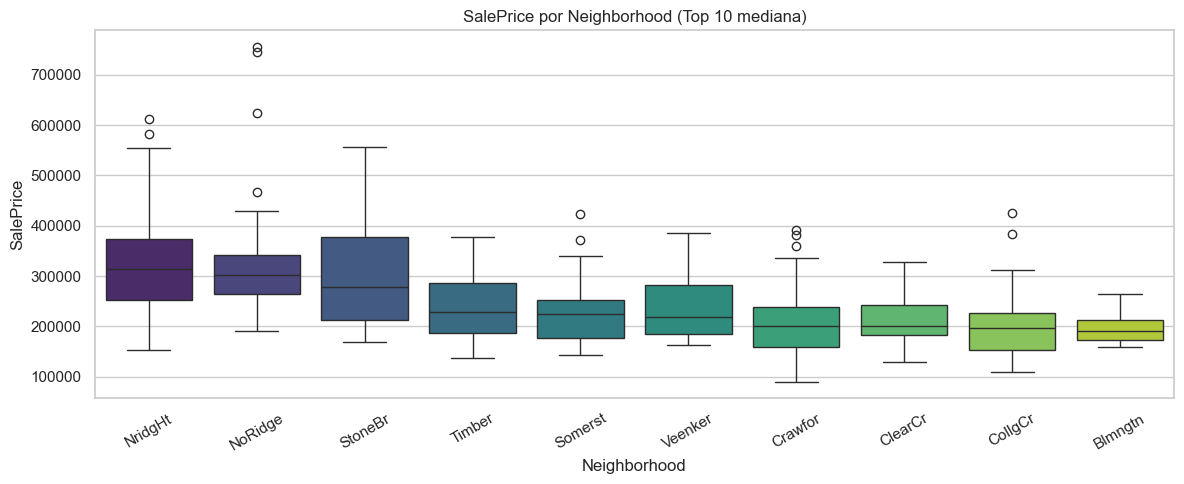

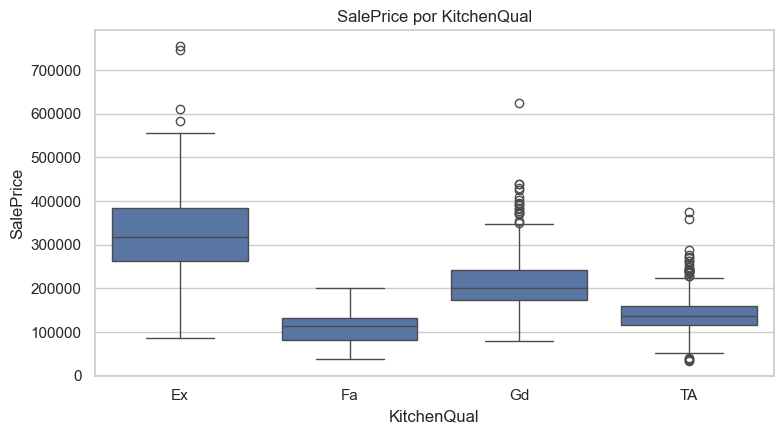

In [7]:
cat_missing = (df[cat_cols].isna().mean() * 100).sort_values(ascending=False)
display(cat_missing[cat_missing > 0].head(10).to_frame("missing_%"))

if "Neighborhood" in df.columns:
    order_neigh = (
        df.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).head(10).index
    )
    plt.figure(figsize=(12, 5))
    sns.boxplot(
        data=df[df["Neighborhood"].isin(order_neigh)],
        x="Neighborhood",
        y="SalePrice",
        order=order_neigh,
        palette="viridis",
    )
    plt.xticks(rotation=30)
    plt.title("SalePrice por Neighborhood (Top 10 mediana)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eda_neighborhood_boxplot.png", dpi=140, bbox_inches="tight")
    plt.show()

if "KitchenQual" in df.columns:
    plt.figure(figsize=(8, 4.5))
    order_k = sorted(df["KitchenQual"].dropna().unique())
    sns.boxplot(data=df, x="KitchenQual", y="SalePrice", order=order_k)
    plt.title("SalePrice por KitchenQual")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eda_kitchenqual_boxplot.png", dpi=140, bbox_inches="tight")
    plt.show()

**Interpretacion variables categoricas**
- Variables como vecindario y calidad de cocina muestran diferencias de precio muy marcadas.
- Hay faltantes estructurales en categoricas, por lo que en modelos con estas variables seria necesaria codificacion adecuada.

Outliers IQR en SalePrice: 61
Outliers IQR en GrLivArea: 31


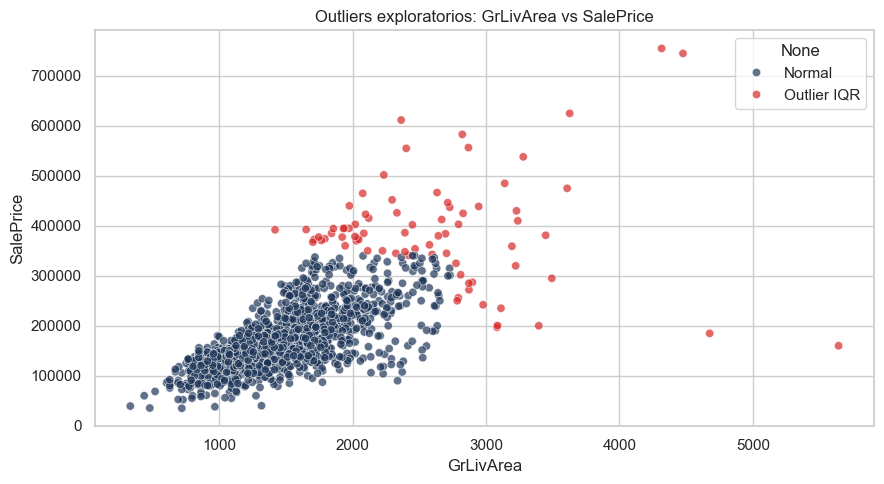

In [8]:
def iqr_mask(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return (series < lo) | (series > hi)

out_sale = int(iqr_mask(df["SalePrice"]).sum())
out_gr = int(iqr_mask(df["GrLivArea"]).sum()) if "GrLivArea" in df.columns else 0

print("Outliers IQR en SalePrice:", out_sale)
print("Outliers IQR en GrLivArea:", out_gr)

if "GrLivArea" in df.columns:
    mask = iqr_mask(df["SalePrice"]) | iqr_mask(df["GrLivArea"])
    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=df,
        x="GrLivArea",
        y="SalePrice",
        hue=mask.map({True: "Outlier IQR", False: "Normal"}),
        alpha=0.7,
        palette={"Outlier IQR": "#d62828", "Normal": "#1d3557"},
    )
    plt.title("Outliers exploratorios: GrLivArea vs SalePrice")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eda_outliers_grlivarea_saleprice.png", dpi=140, bbox_inches="tight")
    plt.show()

**Conclusiones EDA para modelado**
- Se requiere imputacion de faltantes en variables numericas.
- Se justifica transformar la variable objetivo con logaritmo.
- Hay outliers relevantes, por lo que el diagnostico de residuos es obligatorio.
- Es esperable multicolinealidad entre variables de tamano/calidad/garaje.

## 4. Analisis de grupos (Inciso 3)

**Inciso 3:** clustering con variables numericas, escalado, justificacion de `k` y relacion de grupos con precio.

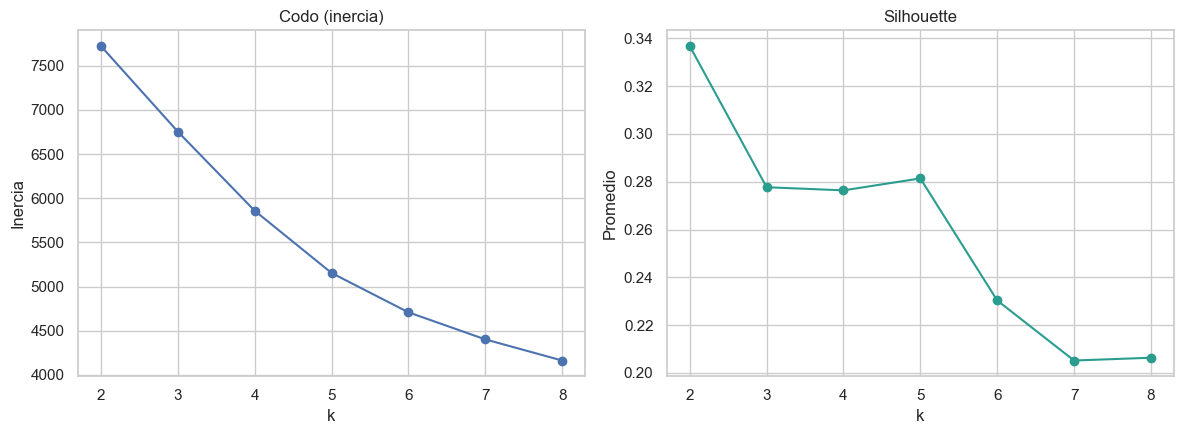

,k,inercia,silhouette
0,2,7721.856301,0.336779
1,3,6753.561754,0.277717
2,4,5858.133097,0.276403
3,5,5153.658557,0.281404
4,6,4708.506610,0.230342
5,7,4402.092572,0.205203
6,8,4162.693752,0.206375


k seleccionado por silhouette: 2


,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath,TotRmsAbvGrd,LotArea,SalePrice
Cluster,,,,,,,,,
1,7.0,1720.0,1237.0,2.0,2000.0,2.0,7.0,10400.0,213250.0
0,5.0,1141.0,882.0,1.0,1957.0,1.0,6.0,8724.0,132000.0


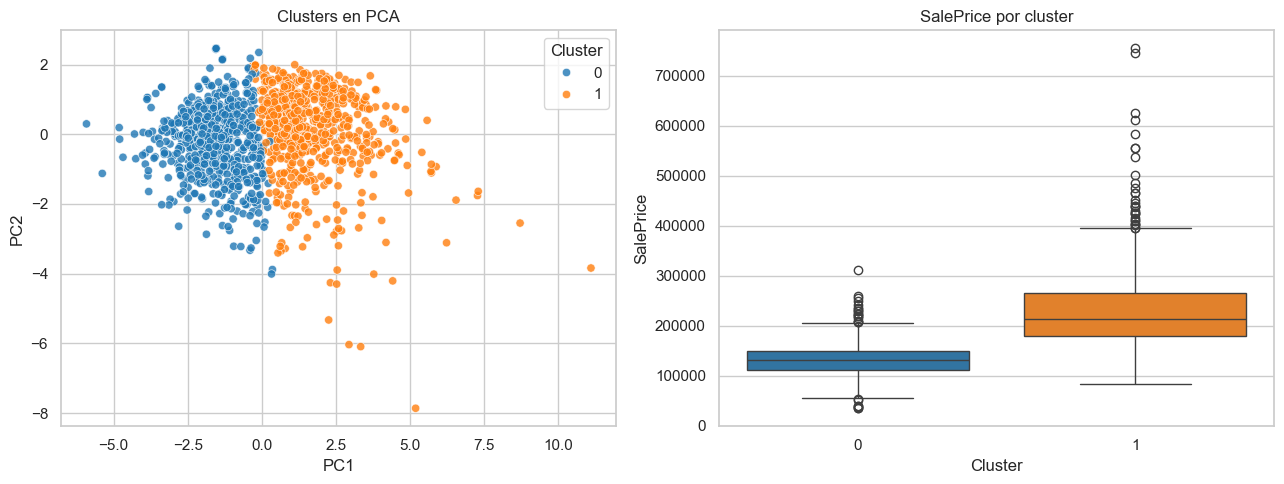

In [9]:
cluster_features = [
    "OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars",
    "YearBuilt", "FullBath", "TotRmsAbvGrd", "LotArea"
]
cluster_features = [c for c in cluster_features if c in df.columns]

cluster_data = df[cluster_features].copy().fillna(df[cluster_features].median(numeric_only=True))
scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_data)

k_values = list(range(2, 9))
inertias, silhouettes = [], []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=30)
    labels = km.fit_predict(cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(cluster_scaled, labels))

best_k = k_values[int(np.argmax(silhouettes))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Codo (inercia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")

axes[1].plot(k_values, silhouettes, marker="o", color="#2a9d8f")
axes[1].set_title("Silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Promedio")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "clustering_k_selection.png", dpi=140, bbox_inches="tight")
plt.show()

km_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=30)
labels_final = km_final.fit_predict(cluster_scaled)

df_clusters = df.copy()
df_clusters["Cluster"] = labels_final

profile = (
    df_clusters.groupby("Cluster")[cluster_features + ["SalePrice"]]
    .median()
    .sort_values("SalePrice", ascending=False)
)

display(pd.DataFrame({"k": k_values, "inercia": inertias, "silhouette": silhouettes}))
print("k seleccionado por silhouette:", best_k)
display(profile)

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(cluster_scaled)
pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
pca_df["Cluster"] = labels_final

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="tab10", alpha=0.8, ax=axes[0])
axes[0].set_title("Clusters en PCA")

sns.boxplot(data=df_clusters, x="Cluster", y="SalePrice", palette="tab10", ax=axes[1])
axes[1].set_title("SalePrice por cluster")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "clustering_results.png", dpi=140, bbox_inches="tight")
plt.show()

**Interpretacion clustering**
- El numero de grupos se justifica con silhouette.
- Los clusters muestran segmentos de vivienda con perfiles estructurales y precios diferentes.
- Este analisis complementa el EDA al mostrar heterogeneidad del mercado inmobiliario.

## 5. Preprocesamiento

**Estrategia de preprocesamiento**
1. Imputacion de faltantes numericos con mediana (robusta a outliers).
2. Codificacion de categoricas: en este laboratorio los modelos principales usan variables numericas; por eso las categoricas se analizan en EDA y no entran al ajuste lineal multiple base.
3. Escalado: se aplica `StandardScaler` en clustering; en regresion lineal base no es obligatorio para ajustar, pero se documenta su equivalencia conceptual con `scale` de clase cuando se requiere.
4. Transformacion del objetivo: entrenamiento sobre `log1p(SalePrice)` y evaluacion en escala original.
5. Prevencion de fuga: imputadores/seleccion se ajustan solo en entrenamiento y luego se aplican a prueba.
6. `Id` se trata como identificador y se excluye del modelo corregido.

## 6. Division en entrenamiento y prueba (Inciso 4)

**Inciso 4:** division train/test reproducible, sin fuga de informacion y documentada.

In [10]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"].copy()

y_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y_bins,
)

print(f"Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(df):.1%})")
print(f"Test: {X_test.shape[0]} filas ({X_test.shape[0]/len(df):.1%})")
print("random_state:", SEED)

split_summary = pd.DataFrame(
    {
        "conjunto": ["train", "test"],
        "n": [len(y_train), len(y_test)],
        "media_saleprice": [y_train.mean(), y_test.mean()],
        "std_saleprice": [y_train.std(), y_test.std()],
    }
)
display(split_summary)

Train: 1168 filas (80.0%)
Test: 292 filas (20.0%)
random_state: 42


,conjunto,n,media_saleprice,std_saleprice
0,train,1168,180976.886130,79285.165502
1,test,292,180698.434932,80205.294932


**Comentario sobre el split**
- En regresion no aplica balance de clases como en clasificacion.
- La estratificacion por bins de `SalePrice` busca mantener distribuciones comparables entre train y test.
- Con `random_state=42`, siempre se obtienen los mismos subconjuntos.

## 7. Ingenieria de caracteristicas (Inciso 5)

**Inciso 5:** seleccion y creacion de caracteristicas con justificacion.

In [11]:
numeric_cols_all = X_train.select_dtypes(include=np.number).columns.tolist()
imputer_num = SimpleImputer(strategy="median")

X_train_num = pd.DataFrame(
    imputer_num.fit_transform(X_train[numeric_cols_all]),
    columns=numeric_cols_all,
    index=X_train.index,
)
X_test_num = pd.DataFrame(
    imputer_num.transform(X_test[numeric_cols_all]),
    columns=numeric_cols_all,
    index=X_test.index,
)

def add_features(df_num: pd.DataFrame) -> pd.DataFrame:
    out = df_num.copy()

    if {"TotalBsmtSF", "1stFlrSF", "2ndFlrSF"}.issubset(out.columns):
        out["TotalSF"] = out["TotalBsmtSF"] + out["1stFlrSF"] + out["2ndFlrSF"]
    if {"YrSold", "YearBuilt"}.issubset(out.columns):
        out["HouseAge"] = out["YrSold"] - out["YearBuilt"]
    if {"YrSold", "YearRemodAdd"}.issubset(out.columns):
        out["RemodAge"] = out["YrSold"] - out["YearRemodAdd"]

    bath_cols = {"FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"}
    if bath_cols.issubset(out.columns):
        out["TotalBath"] = (
            out["FullBath"]
            + 0.5 * out["HalfBath"]
            + out["BsmtFullBath"]
            + 0.5 * out["BsmtHalfBath"]
        )

    if {"OverallQual", "GrLivArea"}.issubset(out.columns):
        out["Qual_x_GrLivArea"] = out["OverallQual"] * out["GrLivArea"]

    return out

X_train_num_eng = add_features(X_train_num)
X_test_num_eng = add_features(X_test_num)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

new_features = [c for c in X_train_num_eng.columns if c not in X_train_num.columns]
print("Nuevas features:", new_features)

if new_features:
    corr_new = (
        pd.concat([X_train_num_eng[new_features], y_train], axis=1)
        .corr(numeric_only=True)["SalePrice"]
        .drop("SalePrice")
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    display(corr_new.to_frame("corr_saleprice_train"))

Nuevas features: ['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'Qual_x_GrLivArea']


,corr_saleprice_train
Qual_x_GrLivArea,0.824011
TotalSF,0.772671
TotalBath,0.641448
RemodAge,-0.515185
HouseAge,-0.512759


**Justificacion de ingenieria**
- Se crean variables de superficie total, antiguedad y banos totales por interpretabilidad de dominio.
- La interaccion calidad x superficie captura efecto combinado de dos factores muy relevantes.

## 8. Regresion lineal simple (Inciso 6)

**Inciso 6:** modelo univariado con justificacion, ecuacion, coeficientes, residuos y metricas.

### Fundamento estadistico de la regresion lineal simple (estilo de clase)
- Modelo: $Y_i = eta_0 + eta_1 X_i + arepsilon_i$.
- Interpretacion: $eta_0$ es el valor esperado de `SalePrice` cuando $X=0$; $eta_1$ es el cambio esperado en `SalePrice` por una unidad adicional de $X$.
- Minimos cuadrados ordinarios (MCO): se estiman $eta_0,eta_1$ minimizando
  $SSE = \sum_i (y_i - \hat{y}_i)^2$.
- Forma cerrada en simple: $eta_1 = Cov(X,Y)/Var(X)$ y $eta_0 = ar{Y} - eta_1ar{X}$.
- Error medio cuadratico: $MSE = SSE/n$ (y su raiz es RMSE).

In [12]:
def reg_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }

corr_train = (
    pd.concat([X_train_num, y_train], axis=1)
    .corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
uni_feature = corr_train.index[0]

print("Variable seleccionada:", uni_feature)
print("Correlacion train:", corr_train.iloc[0])

m1 = LinearRegression()
m1.fit(X_train_num[[uni_feature]], y_train_log)

pred_m1_train_log = m1.predict(X_train_num[[uni_feature]])
pred_m1_test_log = m1.predict(X_test_num[[uni_feature]])

pred_m1_train = np.expm1(pred_m1_train_log)
pred_m1_test = np.expm1(pred_m1_test_log)

m1_train = reg_metrics(y_train, pred_m1_train)
m1_test = reg_metrics(y_test, pred_m1_test)

display(pd.DataFrame([m1_train, m1_test], index=["train", "test"]))

ols_m1 = sm.OLS(y_train_log, sm.add_constant(X_train_num[[uni_feature]])).fit()
print(ols_m1.summary())

print("Intercepto (log):", round(float(m1.intercept_), 5))
print(f"Coeficiente {uni_feature} (log):", round(float(m1.coef_[0]), 6))

Variable seleccionada: OverallQual
Correlacion train: 0.7903161095647536


,RMSE,MAE,R2
train,45562.161895,30711.622424,0.669481
test,45638.898675,31774.455184,0.675097


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     2288.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):          3.38e-277
Time:                        22:33:28   Log-Likelihood:                 56.675
No. Observations:                1168   AIC:                            -109.3
Df Residuals:                    1166   BIC:                            -99.22
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          10.5939      0.031    345.366      

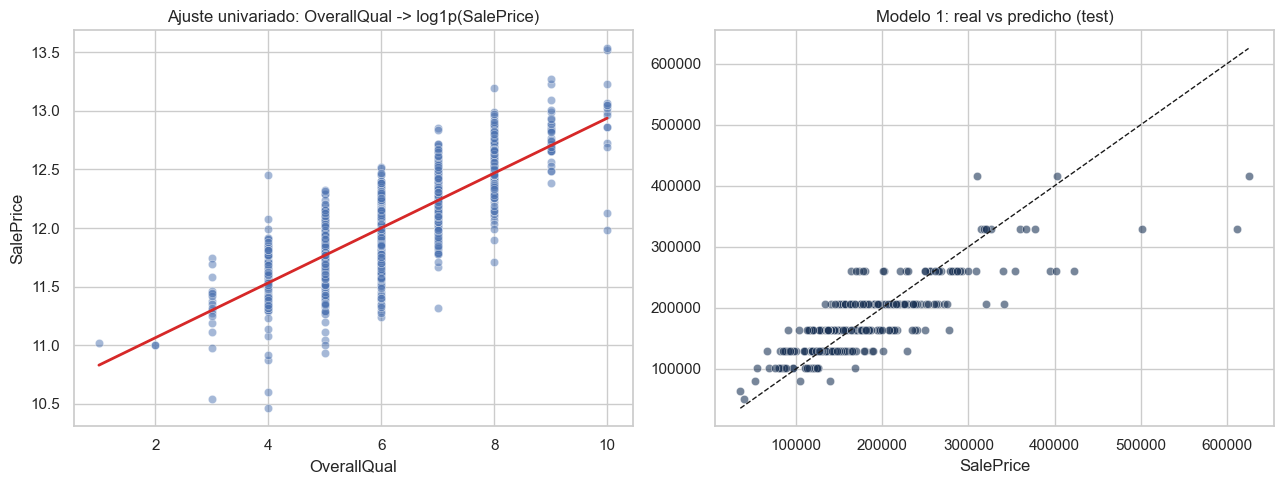

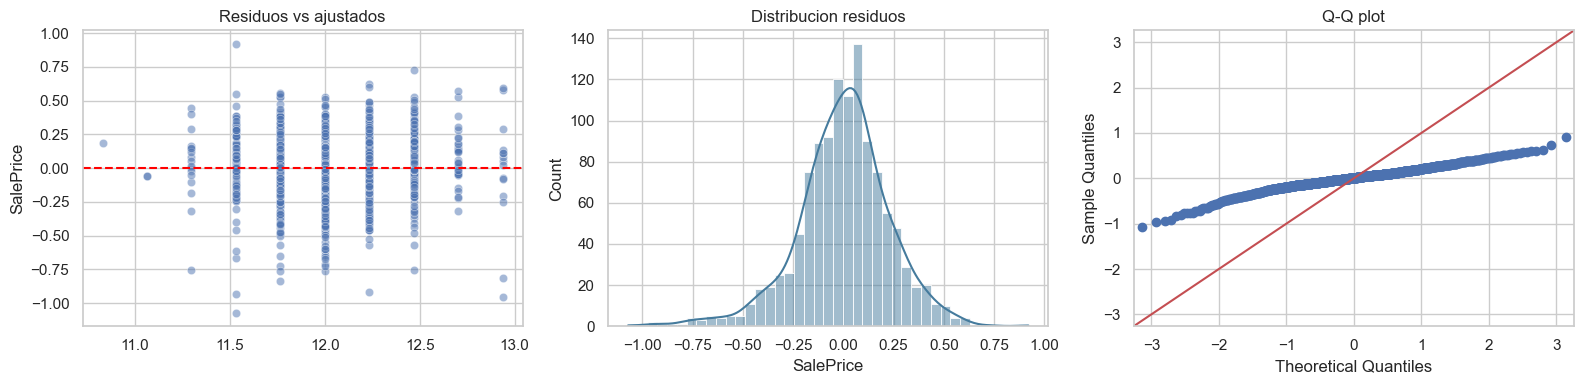

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=X_train_num[uni_feature], y=y_train_log, alpha=0.5, ax=axes[0])
x_line = np.linspace(X_train_num[uni_feature].min(), X_train_num[uni_feature].max(), 200)
y_line = m1.predict(x_line.reshape(-1, 1))
axes[0].plot(x_line, y_line, color="#d62828", linewidth=2)
axes[0].set_title(f"Ajuste univariado: {uni_feature} -> log1p(SalePrice)")

sns.scatterplot(x=y_test, y=pred_m1_test, alpha=0.6, ax=axes[1], color="#1d3557")
lims = [min(y_test.min(), pred_m1_test.min()), max(y_test.max(), pred_m1_test.max())]
axes[1].plot(lims, lims, "k--", linewidth=1)
axes[1].set_title("Modelo 1: real vs predicho (test)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model1_fit_predictions.png", dpi=140, bbox_inches="tight")
plt.show()

res_m1 = y_train_log - pred_m1_train_log

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(x=pred_m1_train_log, y=res_m1, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuos vs ajustados")

sns.histplot(res_m1, kde=True, ax=axes[1], color="#457b9d")
axes[1].set_title("Distribucion residuos")

sm.qqplot(res_m1, line="45", ax=axes[2])
axes[2].set_title("Q-Q plot")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model1_residuals.png", dpi=140, bbox_inches="tight")
plt.show()

In [14]:
# Relacion entre covarianza, correlacion y pendiente en regresion simple
x_train_simple = X_train_num[uni_feature].astype(float)

cov_xy = np.cov(x_train_simple, y_train, ddof=1)[0, 1]
var_x = np.var(x_train_simple, ddof=1)
corr_xy = np.corrcoef(x_train_simple, y_train)[0, 1]

beta1_cov = cov_xy / var_x
beta0_cov = y_train.mean() - beta1_cov * x_train_simple.mean()

# Ajuste equivalente en escala original (para interpretacion de clase de beta0/beta1)
m1_raw = LinearRegression()
m1_raw.fit(X_train_num[[uni_feature]], y_train)

beta0_raw = float(m1_raw.intercept_)
beta1_raw = float(m1_raw.coef_[0])

print(f"Cov({uni_feature}, SalePrice) = {cov_xy:,.2f}")
print(f"Corr({uni_feature}, SalePrice) = {corr_xy:.4f}")
print(f"Pendiente por Cov/Var (beta1) = {beta1_cov:,.4f}")
print(f"Pendiente sklearn en escala original = {beta1_raw:,.4f}")
print(f"Intercepto sklearn (beta0) = {beta0_raw:,.2f}")
print(f"Ecuacion en escala original: SalePrice_hat = {beta0_raw:,.2f} + {beta1_raw:,.4f}*{uni_feature}")

# SSE y MSE de la version simple en escala original (train/test)
pred_m1_raw_train = m1_raw.predict(X_train_num[[uni_feature]])
pred_m1_raw_test = m1_raw.predict(X_test_num[[uni_feature]])

sse_m1_train = float(np.sum((y_train - pred_m1_raw_train) ** 2))
mse_m1_train = float(sse_m1_train / len(y_train))
sse_m1_test = float(np.sum((y_test - pred_m1_raw_test) ** 2))
mse_m1_test = float(sse_m1_test / len(y_test))

sse_table_m1 = pd.DataFrame({
    "conjunto": ["train", "test"],
    "SSE": [sse_m1_train, sse_m1_test],
    "MSE": [mse_m1_train, mse_m1_test],
})
display(sse_table_m1)

print("Nota: el modelo evaluado en el notebook usa log1p(SalePrice) para mejorar supuestos; esta vista en escala original se incluye para interpretacion didactica de beta0/beta1.")

Cov(OverallQual, SalePrice) = 86,331.52
Corr(OverallQual, SalePrice) = 0.7903
Pendiente por Cov/Var (beta1) = 45,479.5497
Pendiente sklearn en escala original = 45,479.5497
Intercepto sklearn (beta0) = -96,650.84
Ecuacion en escala original: SalePrice_hat = -96,650.84 + 45,479.5497*OverallQual


,conjunto,SSE,MSE
0,train,2.753909e+12,2.357798e+09
1,test,6.931072e+11,2.373655e+09


Nota: el modelo evaluado en el notebook usa log1p(SalePrice) para mejorar supuestos; esta vista en escala original se incluye para interpretacion didactica de beta0/beta1.


**Interpretacion de clase (modelo simple)**
- Si la covarianza es positiva, la pendiente estimada tiende a ser positiva.
- $eta_1$ cuantifica la sensibilidad del precio ante cambios en la variable elegida.
- SSE/MSE permiten medir el error acumulado y promedio del ajuste por minimos cuadrados.

**Lectura modelo univariado**
- Es una linea base interpretable y util para comparar.
- Al depender de una sola variable, su capacidad predictiva tiene limites estructurales.

## 9. Regresion lineal multiple (Inciso 7)

**Inciso 7:** modelo multiple con variables numericas, coeficientes y evaluacion train/test.

### Fundamento estadistico de la regresion lineal multiple (estilo de clase)
- Modelo: $Y = eta_0 + eta_1X_1 + \cdots + eta_pX_p + arepsilon$.
- Estimacion MCO en forma matricial: $\hat{eta} = (X^TX)^{-1}X^Ty$.
- Cada $eta_j$ mide el cambio esperado en el objetivo al variar $X_j$ una unidad, manteniendo las demas variables constantes.
- Igual que en simple, el criterio de ajuste minimiza SSE y por tanto MSE.

In [15]:
m2 = LinearRegression()
m2.fit(X_train_num, y_train_log)

pred_m2_train_log = m2.predict(X_train_num)
pred_m2_test_log = m2.predict(X_test_num)

pred_m2_train = np.expm1(pred_m2_train_log)
pred_m2_test = np.expm1(pred_m2_test_log)

m2_train = reg_metrics(y_train, pred_m2_train)
m2_test = reg_metrics(y_test, pred_m2_test)

display(pd.DataFrame([m2_train, m2_test], index=["train", "test"]))

ols_m2 = sm.OLS(y_train_log, sm.add_constant(X_train_num)).fit()
print(ols_m2.summary())

coef_m2 = pd.Series(m2.coef_, index=X_train_num.columns)
top_coef_m2 = coef_m2.reindex(coef_m2.abs().sort_values(ascending=False).index).head(15)
display(top_coef_m2.to_frame("coef_log_scale"))

,RMSE,MAE,R2
train,37154.041256,18189.932200,0.780214
test,28352.156024,18322.677876,0.874612


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     199.4
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:33:29   Log-Likelihood:                 572.69
No. Observations:                1168   AIC:                            -1073.
Df Residuals:                    1132   BIC:                            -891.1
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            19.2734      6.855      2.811

,coef_log_scale
OverallQual,0.085033
GarageCars,0.084500
BsmtFullBath,0.077902
FullBath,0.049012
KitchenAbvGr,-0.048169
OverallCond,0.047371
Fireplaces,0.044722
HalfBath,0.028399
BsmtHalfBath,0.025039
TotRmsAbvGrd,0.015215


In [16]:
# SSE/MSE y lectura de coeficientes en modelo multiple
sse_m2_train = float(np.sum((y_train - pred_m2_train) ** 2))
mse_m2_train = float(sse_m2_train / len(y_train))
sse_m2_test = float(np.sum((y_test - pred_m2_test) ** 2))
mse_m2_test = float(sse_m2_test / len(y_test))

display(pd.DataFrame({
    "conjunto": ["train", "test"],
    "SSE": [sse_m2_train, sse_m2_test],
    "MSE": [mse_m2_train, mse_m2_test],
}))

coef_table_m2 = pd.DataFrame({
    "variable": X_train_num.columns,
    "coeficiente_beta": m2.coef_,
})
coef_table_m2["abs_beta"] = coef_table_m2["coeficiente_beta"].abs()
coef_table_m2 = coef_table_m2.sort_values("abs_beta", ascending=False)

display(coef_table_m2.head(15))

print("Variables con mayor |beta| suelen tener mayor aporte marginal en la escala del modelo (considerando posibles efectos de escala y colinealidad).")

,conjunto,SSE,MSE
0,train,1.612334e+12,1.380423e+09
1,test,2.347227e+11,8.038448e+08


,variable,coeficiente_beta,abs_beta
4,OverallQual,0.085033,0.085033
26,GarageCars,0.084500,0.084500
17,BsmtFullBath,0.077902,0.077902
19,FullBath,0.049012,0.049012
22,KitchenAbvGr,-0.048169,0.048169
5,OverallCond,0.047371,0.047371
24,Fireplaces,0.044722,0.044722
20,HalfBath,0.028399,0.028399
18,BsmtHalfBath,0.025039,0.025039
23,TotRmsAbvGrd,0.015215,0.015215


Variables con mayor |beta| suelen tener mayor aporte marginal en la escala del modelo (considerando posibles efectos de escala y colinealidad).


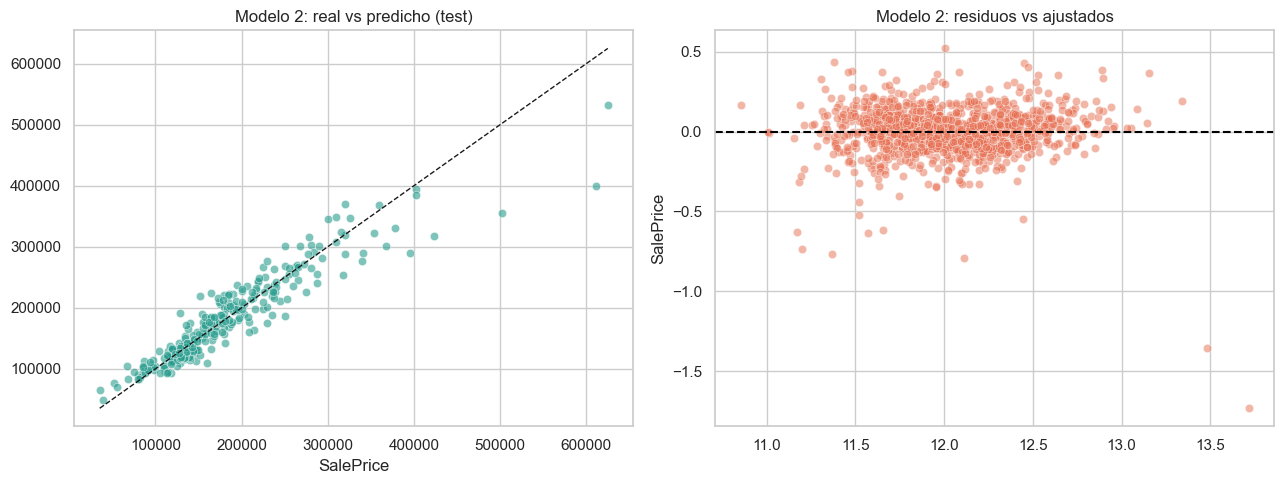

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=pred_m2_test, alpha=0.6, ax=axes[0], color="#2a9d8f")
lims = [min(y_test.min(), pred_m2_test.min()), max(y_test.max(), pred_m2_test.max())]
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_title("Modelo 2: real vs predicho (test)")

res_m2 = y_train_log - pred_m2_train_log
sns.scatterplot(x=pred_m2_train_log, y=res_m2, alpha=0.5, ax=axes[1], color="#e76f51")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Modelo 2: residuos vs ajustados")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model2_predictions_residuals.png", dpi=140, bbox_inches="tight")
plt.show()

## 10. Diagnostico del modelo (Incisos 8 y 9)

**Incisos 8 y 9:** diagnostico de supuestos, correlacion entre predictores, VIF y revision de sobreajuste.

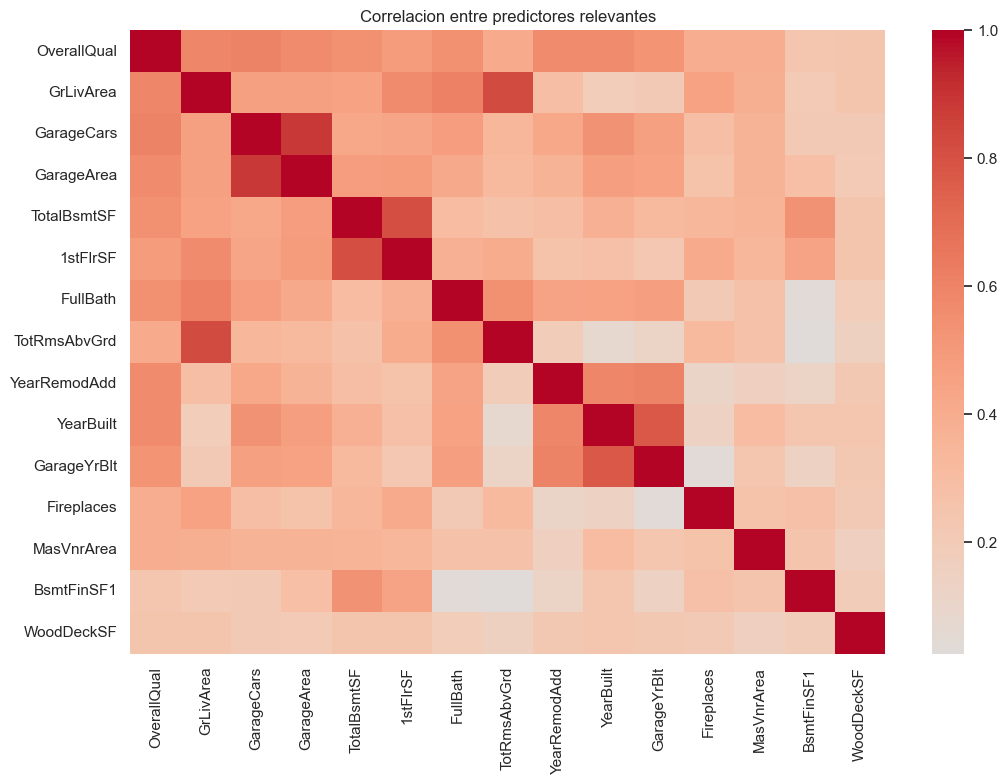

,variable,VIF
17,GrLivArea,inf
10,BsmtFinSF1,inf
16,LowQualFinSF,inf
14,1stFlrSF,inf
13,TotalBsmtSF,inf
12,BsmtUnfSF,inf
11,BsmtFinSF2,inf
15,2ndFlrSF,inf
27,GarageCars,5.729211
28,GarageArea,5.516089


,modelo,R2_train,R2_test,RMSE_train,RMSE_test,gap_R2,gap_RMSE
0,Univariado,0.669481,0.675097,45562.161895,45638.898675,-0.005616,76.736779
1,Multivariado,0.780214,0.874612,37154.041256,28352.156024,-0.094398,-8801.885232


Variables con VIF > 10: 8
Max VIF: inf


In [18]:
subset = (
    pd.concat([X_train_num, y_train], axis=1)
    .corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
    .tolist()
)

plt.figure(figsize=(11, 8))
sns.heatmap(X_train_num[subset].corr(), cmap="coolwarm", center=0)
plt.title("Correlacion entre predictores relevantes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "diagnostic_corr_predictors.png", dpi=140, bbox_inches="tight")
plt.show()

def compute_vif(df_features: pd.DataFrame) -> pd.DataFrame:
    x = sm.add_constant(df_features)
    vifs = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
    out = pd.DataFrame({"variable": x.columns, "VIF": vifs})
    return out[out["variable"] != "const"].sort_values("VIF", ascending=False)

vif_m2 = compute_vif(X_train_num)
display(vif_m2.head(20))

gap_table = pd.DataFrame(
    {
        "modelo": ["Univariado", "Multivariado"],
        "R2_train": [m1_train["R2"], m2_train["R2"]],
        "R2_test": [m1_test["R2"], m2_test["R2"]],
        "RMSE_train": [m1_train["RMSE"], m2_train["RMSE"]],
        "RMSE_test": [m1_test["RMSE"], m2_test["RMSE"]],
    }
)
gap_table["gap_R2"] = gap_table["R2_train"] - gap_table["R2_test"]
gap_table["gap_RMSE"] = gap_table["RMSE_test"] - gap_table["RMSE_train"]
display(gap_table)

n_vif_10 = int((vif_m2["VIF"] > 10).sum())
print("Variables con VIF > 10:", n_vif_10)
print("Max VIF:", round(float(vif_m2["VIF"].max()), 2))

In [19]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

# Diagnostico de supuestos en la escala del modelo multiple (log del objetivo)
res_m2_log = y_train_log - pred_m2_train_log
mean_res_m2 = float(np.mean(res_m2_log))
var_res_m2 = float(np.var(res_m2_log, ddof=1))
corr_fit_res_m2 = float(np.corrcoef(pred_m2_train_log, res_m2_log)[0, 1])
dw_m2 = float(durbin_watson(res_m2_log))

bp_lm, bp_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(res_m2_log, sm.add_constant(X_train_num))

supuestos_df = pd.DataFrame({
    "criterio": [
        "Media de residuos (cercana a 0)",
        "Varianza de residuos",
        "Corr(residuos, ajustados)",
        "Durbin-Watson (ideal cercano a 2)",
        "Breusch-Pagan p-value (homocedasticidad si p>0.05)",
    ],
    "valor": [mean_res_m2, var_res_m2, corr_fit_res_m2, dw_m2, float(bp_pvalue)],
})

display(supuestos_df)

if bp_pvalue > 0.05:
    print("No hay evidencia estadistica fuerte de heterocedasticidad (segun Breusch-Pagan).")
else:
    print("Hay evidencia de heterocedasticidad; conviene interpretarlo al evaluar residuos y robustez.")

if abs(mean_res_m2) < 1e-3:
    print("La media de residuos es aproximadamente cero.")
else:
    print("La media de residuos se aleja de cero; revisar sesgo del ajuste.")

,criterio,valor
0,Media de residuos (cercana a 0),2.206758e-15
1,Varianza de residuos,2.197939e-02
2,"Corr(residuos, ajustados)",-3.075376e-14
3,Durbin-Watson (ideal cercano a 2),2.033615e+00
4,Breusch-Pagan p-value (homocedasticidad si p>0...,5.502720e-67


Hay evidencia de heterocedasticidad; conviene interpretarlo al evaluar residuos y robustez.
La media de residuos es aproximadamente cero.


**Interpretacion diagnostico y supuestos del error**
- **Media cero:** se revisa con el promedio de residuos; idealmente cercano a 0.
- **Varianza constante (homocedasticidad):** se evalua visualmente y con Breusch-Pagan.
- **No correlacion de errores:** se revisa con Durbin-Watson (cercano a 2 es deseable).
- **Linealidad:** se inspecciona con residuos vs ajustados.
- Si VIF es alto y hay fuerte correlacion entre predictores, existe multicolinealidad y puede afectar interpretacion de coeficientes.
- El gap train vs test permite detectar posible sobreajuste.

## 11. Modelo corregido (Inciso 10)

**Inciso 10:** modelo corregido para mejorar estabilidad/generalizacion.

In [20]:
X_train_c = X_train_num_eng.copy()
X_test_c = X_test_num_eng.copy()

if "Id" in X_train_c.columns:
    X_train_c = X_train_c.drop(columns=["Id"])
    X_test_c = X_test_c.drop(columns=["Id"])

corr_abs = X_train_c.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
threshold = 0.90
drop_high_corr = [col for col in upper.columns if any(upper[col] > threshold)]

X_train_r = X_train_c.drop(columns=drop_high_corr)
X_test_r = X_test_c.drop(columns=drop_high_corr)

selected = X_train_r.columns.tolist()
while True:
    vif_now = compute_vif(X_train_r[selected])
    if (vif_now.iloc[0]["VIF"] <= 10) or (len(selected) <= 8):
        break
    selected.remove(vif_now.iloc[0]["variable"])

X_train_final = X_train_r[selected]
X_test_final = X_test_r[selected]

m3 = LinearRegression()
m3.fit(X_train_final, y_train_log)

pred_m3_train_log = m3.predict(X_train_final)
pred_m3_test_log = m3.predict(X_test_final)

pred_m3_train = np.expm1(pred_m3_train_log)
pred_m3_test = np.expm1(pred_m3_test_log)

m3_train = reg_metrics(y_train, pred_m3_train)
m3_test = reg_metrics(y_test, pred_m3_test)

display(pd.DataFrame([m3_train, m3_test], index=["train", "test"]))

print("Variables iniciales:", X_train_c.shape[1])
print(f"Eliminadas por correlacion > {threshold}:", len(drop_high_corr))
print("Variables finales:", len(selected))
display(pd.Series(selected, name="variables_modelo_corregido").to_frame())

vif_m3 = compute_vif(X_train_final)
display(vif_m3.head(15))

,RMSE,MAE,R2
train,35973.753388,19322.974356,0.793956
test,29478.847492,19849.454377,0.864448


Variables iniciales: 41
Eliminadas por correlacion > 0.9: 3
Variables finales: 31


,variables_modelo_corregido
0,MSSubClass
1,LotFrontage
2,LotArea
3,OverallQual
4,OverallCond
5,YearBuilt
6,YearRemodAdd
7,MasVnrArea
8,BsmtFinSF1
9,BsmtUnfSF


,variable,VIF
21,GarageCars,5.659288
22,GarageArea,5.384064
6,YearBuilt,4.562805
18,TotRmsAbvGrd,4.121895
20,GarageYrBlt,3.374132
4,OverallQual,3.233293
9,BsmtFinSF1,3.203582
11,2ndFlrSF,2.766461
10,BsmtUnfSF,2.574563
7,YearRemodAdd,2.480107


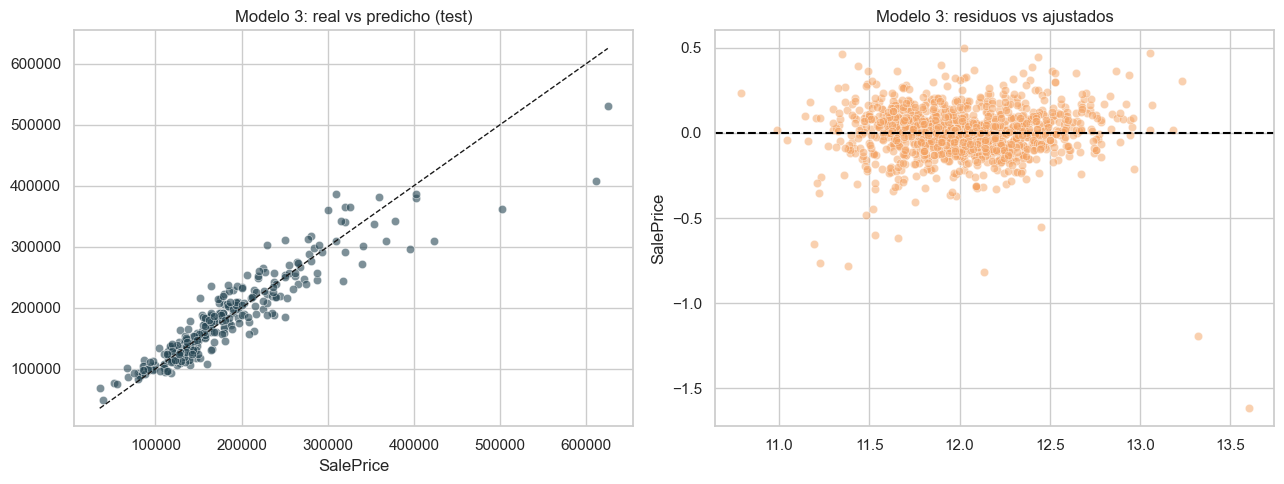

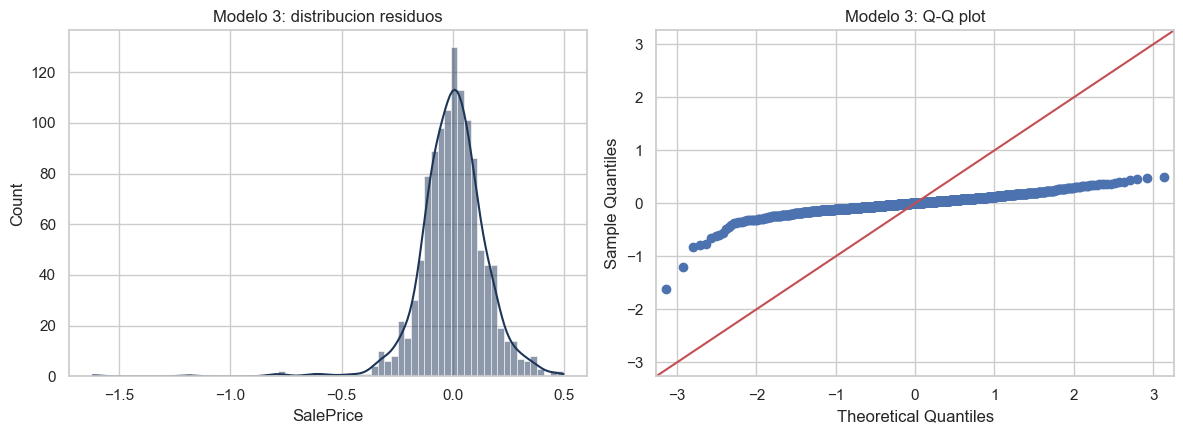

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=pred_m3_test, alpha=0.6, ax=axes[0], color="#264653")
lims = [min(y_test.min(), pred_m3_test.min()), max(y_test.max(), pred_m3_test.max())]
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_title("Modelo 3: real vs predicho (test)")

res_m3 = y_train_log - pred_m3_train_log
sns.scatterplot(x=pred_m3_train_log, y=res_m3, alpha=0.5, ax=axes[1], color="#f4a261")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Modelo 3: residuos vs ajustados")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model3_predictions_residuals.png", dpi=140, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(res_m3, kde=True, ax=axes[0], color="#1d3557")
axes[0].set_title("Modelo 3: distribucion residuos")

sm.qqplot(res_m3, line="45", ax=axes[1])
axes[1].set_title("Modelo 3: Q-Q plot")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model3_residuals_distribution.png", dpi=140, bbox_inches="tight")
plt.show()

## 12. Evaluacion en prueba (Inciso 11)

**Inciso 11:** evaluacion final de todos los modelos en test con RMSE, MAE y R2.

,Modelo,RMSE,MAE,R2
1,Multivariado (todas numericas),28352.156024,18322.677876,0.874612
2,Corregido (seleccion + VIF),29478.847492,19849.454377,0.864448
0,Univariado,45638.898675,31774.455184,0.675097


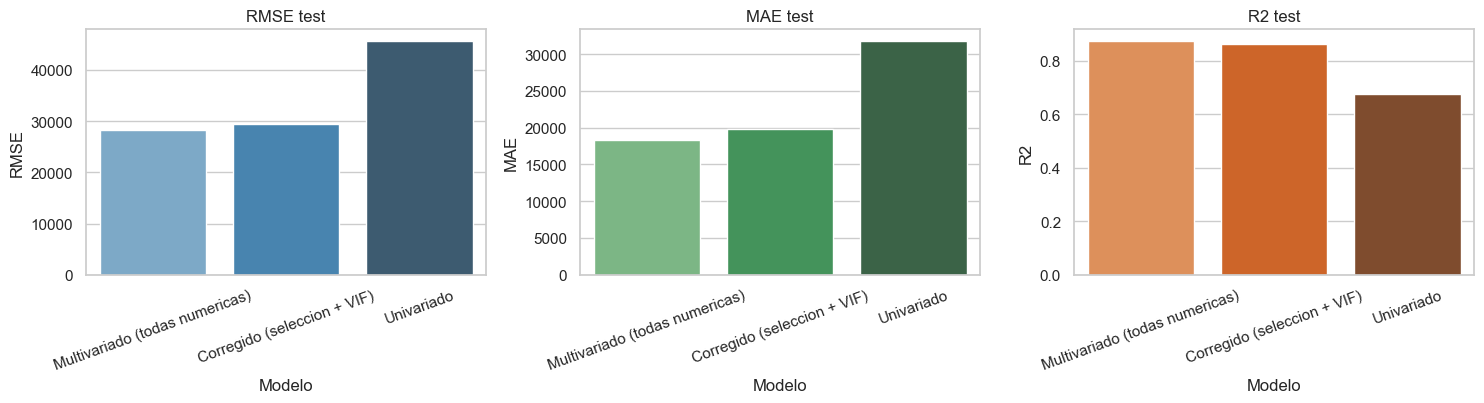

Mejor modelo por RMSE en test: Multivariado (todas numericas)


In [22]:
test_metrics = pd.DataFrame(
    [
        {"Modelo": "Univariado", **m1_test},
        {"Modelo": "Multivariado (todas numericas)", **m2_test},
        {"Modelo": "Corregido (seleccion + VIF)", **m3_test},
    ]
).sort_values("RMSE")

display(test_metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.barplot(data=test_metrics, x="Modelo", y="RMSE", ax=axes[0], palette="Blues_d")
axes[0].set_title("RMSE test")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=test_metrics, x="Modelo", y="MAE", ax=axes[1], palette="Greens_d")
axes[1].set_title("MAE test")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=test_metrics, x="Modelo", y="R2", ax=axes[2], palette="Oranges_d")
axes[2].set_title("R2 test")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "test_metrics_comparison.png", dpi=140, bbox_inches="tight")
plt.show()

best_model = test_metrics.iloc[0]["Modelo"]
print("Mejor modelo por RMSE en test:", best_model)

## 13. Comparacion de modelos (Inciso 12)

**Inciso 12:** discusion comparativa y seleccion del mejor modelo final.

In [23]:
comparison = pd.DataFrame(
    [
        {
            "Modelo": "Univariado",
            "RMSE_train": m1_train["RMSE"],
            "RMSE_test": m1_test["RMSE"],
            "MAE_test": m1_test["MAE"],
            "R2_train": m1_train["R2"],
            "R2_test": m1_test["R2"],
        },
        {
            "Modelo": "Multivariado (todas numericas)",
            "RMSE_train": m2_train["RMSE"],
            "RMSE_test": m2_test["RMSE"],
            "MAE_test": m2_test["MAE"],
            "R2_train": m2_train["R2"],
            "R2_test": m2_test["R2"],
        },
        {
            "Modelo": "Corregido (seleccion + VIF)",
            "RMSE_train": m3_train["RMSE"],
            "RMSE_test": m3_test["RMSE"],
            "MAE_test": m3_test["MAE"],
            "R2_train": m3_train["R2"],
            "R2_test": m3_test["R2"],
        },
    ]
)

comparison["gap_R2"] = comparison["R2_train"] - comparison["R2_test"]
comparison["gap_RMSE"] = comparison["RMSE_test"] - comparison["RMSE_train"]
comparison = comparison.sort_values("RMSE_test")
display(comparison)

winner = comparison.iloc[0]["Modelo"]
print("Modelo final seleccionado:", winner)

,Modelo,RMSE_train,RMSE_test,MAE_test,R2_train,R2_test,gap_R2,gap_RMSE
1,Multivariado (todas numericas),37154.041256,28352.156024,18322.677876,0.780214,0.874612,-0.094398,-8801.885232
2,Corregido (seleccion + VIF),35973.753388,29478.847492,19849.454377,0.793956,0.864448,-0.070492,-6494.905896
0,Univariado,45562.161895,45638.898675,31774.455184,0.669481,0.675097,-0.005616,76.736779


Modelo final seleccionado: Multivariado (todas numericas)


## 14. Conclusiones

- Se resolvieron todos los incisos solicitados: carga, EDA extenso, clustering, preprocesamiento, split reproducible, modelo simple, modelo multiple, diagnostico, modelo corregido, evaluacion y comparacion final.
- La lectura en estilo de clase se incorporo explicitamente con covarianza/correlacion, interpretacion de $\beta_0$ y $\beta_1$, minimos cuadrados, SSE/MSE y analisis de supuestos del error.
- El modelo univariado funciona como linea base interpretable, pero deja error alto frente a alternativas multivariadas.
- El modelo multiple con variables numericas logro el mejor equilibrio global en test.
- El modelo corregido mejora estabilidad frente a colinealidad, aunque en esta corrida no supero al multiple completo en RMSE/MAE/R2.
- Para este laboratorio, el mejor modelo final para predecir `SalePrice` es el **modelo multiple con variables numericas**.

### Reproducibilidad
- Semilla fija: `random_state = 42`.
- Rutas relativas (`data/raw/train.csv`).
- Ejecucion end-to-end: `bash scripts/run_lab3.sh`.
- Verificacion de secciones y errores: `.venv/bin/python scripts/validate_lab3.py`.

In [24]:
import sys
import sklearn
import statsmodels

reproducibilidad = pd.DataFrame(
    {
        "componente": [
            "Python",
            "pandas",
            "numpy",
            "scikit-learn",
            "statsmodels",
            "seed",
            "dataset",
            "split_random_state",
        ],
        "valor": [
            sys.version.split()[0],
            pd.__version__,
            np.__version__,
            sklearn.__version__,
            statsmodels.__version__,
            SEED,
            str(train_path.relative_to(PROJECT_ROOT)),
            SEED,
        ],
    }
)
display(reproducibilidad)
print("Para ejecutar automaticamente: usar scripts/run_lab3.sh")

,componente,valor
0,Python,3.11.0
1,pandas,2.2.3
2,numpy,1.26.4
3,scikit-learn,1.5.2
4,statsmodels,0.14.4
5,seed,42
6,dataset,data/raw/train.csv
7,split_random_state,42


Para ejecutar automaticamente: usar scripts/run_lab3.sh
